In [110]:
import os
import shutil
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm
import librosa
import librosa.display
import soundfile as sf
import sounddevice as sd

In [111]:
def envelope(y, threshold=0.1, sr=16000):
    mask = []
    y = pd.Series(y).apply(np.abs)
    y_mean = y.rolling(window=int(sr/20),
                       min_periods=1,
                       center=True).max()
    
    for mean in y_mean:
        if mean > threshold:
            mask.append(True)
        else:
            mask.append(False)

    return mask, y_mean

In [112]:
def remove_silence_using_mask(y, threshold=0.1, sr=16000):
    mask, _ = envelope(y, threshold, sr)
    new_signal = []

    for i, val in enumerate(y):
        if mask[i]:
            new_signal.append(val)
            
    return np.array(new_signal)

In [126]:
def normalize_signal(path):
    y, sr = librosa.load(path, sr=None) 
    max_amplitude = np.max(np.abs(y))
    
    return y / max_amplitude, sr

In [114]:
def segment_signal(y, delta_time=1, sr=16000):
    segment_length = int(delta_time * sr)
    segments = [y[i:i + segment_length] for i in range(0, len(y), segment_length)]
    
    fixed_segments = []
    for segment in segments:
        if len(segment) < segment_length:
            fixed_segments.append(np.pad(segment, (0, segment_length - len(segment)), mode='constant', constant_values=0))
        else:
            fixed_segments.append(segment)


    return fixed_segments

In [115]:
def create_clean_dir(df, origin_dir, clean_dir, segmented_dir, threshold=0.1, delta_time = 1):
    origin_dir = Path(origin_dir)
    clean_dir = Path(clean_dir)
    segmented_dir = Path(segmented_dir)
    
    if clean_dir.exists() and len(os.listdir(clean_dir)) != 0:
        shutil.rmtree(clean_dir)
    clean_dir.mkdir(parents=True, exist_ok=True)
    if segmented_dir.exists() and len(os.listdir(segmented_dir)) != 0:
        shutil.rmtree(segmented_dir)
    segmented_dir.mkdir(parents=True, exist_ok=True)

    for f in tqdm(df.fname):
        y, sr = normalize_signal(origin_dir / f)
        cleaned_signal = remove_silence_using_mask(y, threshold, sr)
        segments = segment_signal(cleaned_signal, delta_time, sr)
        sf.write(clean_dir / f, cleaned_signal, sr)

        for i, segment in enumerate(segments):
            if len(segment) >= delta_time * sr:
                segment_filename = Path(f).stem + f'_{i}.wav'
                sf.write(segmented_dir / segment_filename, segment, sr)

Load train/test DataFrame

In [116]:
train_csv_path = 'meta/train_post_competition.csv'
train_df = pd.read_csv(train_csv_path)

test_csv_path = 'meta/test_post_competition_scoring_clips.csv'
test_df = pd.read_csv(test_csv_path)

In [117]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]
test_df = test_df[test_df['label'].isin(musical_instruments)]

In [118]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('train', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

test_df = test_df[test_df['fname'].apply(lambda x: os.path.exists(os.path.join('test', x)))]
test_df = test_df.reset_index(drop=True)

In [119]:
print(train_df.label.value_counts().sort_index())

Acoustic_guitar     105
Bass_drum            67
Cello               125
Clarinet            130
Cowbell              96
Double_bass          92
Electric_piano       74
Flute               128
Glockenspiel         70
Harmonica            88
Hi-hat               89
Oboe                 99
Saxophone           256
Tambourine           92
Trumpet              86
Violin_or_fiddle    250
Name: label, dtype: int64


In [120]:
print(test_df.label.value_counts().sort_index())

Acoustic_guitar      45
Bass_drum            28
Cello                54
Clarinet             56
Cowbell              42
Double_bass          40
Electric_piano       32
Flute                55
Glockenspiel         29
Harmonica            33
Hi-hat               39
Oboe                 42
Saxophone           110
Tambourine           40
Trumpet              37
Violin_or_fiddle    108
Name: label, dtype: int64


Create clean directories

In [121]:
create_clean_dir(train_df, 'train', 'clean_train', 'segmented_train')
create_clean_dir(test_df, 'test', 'clean_test', 'segmented_test')

100%|██████████| 790/790 [00:48<00:00, 16.45it/s]


Plot envelope

In [127]:
def plot_envelope(df, origin_dir, i=0, threshold=0.1):
    origin_dir = Path(origin_dir)
    y, sr = normalize_signal(origin_dir / df.fname[i])
    mask, mean = envelope(y, threshold, sr)
    mask = np.array(mask)
    y_remove = np.copy(y)
    y_remove[mask] = np.nan
    y_keep = np.copy(y)
    y_keep[~mask] = np.nan
    plt.title('Signal Envelope | Threshold = {}'.format(str(threshold)))
    plt.plot(mean, color='m', label='envelope')
    plt.plot(y_remove, color='r', label='remove')
    plt.plot(y_keep, color='c', label='keep')
    plt.legend(loc='best')
    plt.show()

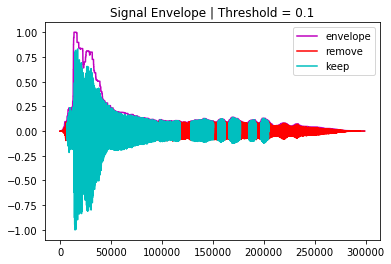

In [128]:
i = 8

plot_envelope(train_df, 'train', i, 0.1)

# y, sr = sf.read('train/' + train_df['fname'][i])
# sd.play(y, sr)

Plot mel spectrogram

In [129]:
def plot_melspectrogram(df, clean_dir, i=0, n_mels=128):
    clean_dir = Path(clean_dir)
    y, sr = librosa.load(clean_dir / df.fname[i], sr=None)
    melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                    sr=sr, 
                                                    n_mels=n_mels, 
                                                    fmax=sr/2)
    melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
    librosa.display.specshow(melspectrogram_db, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

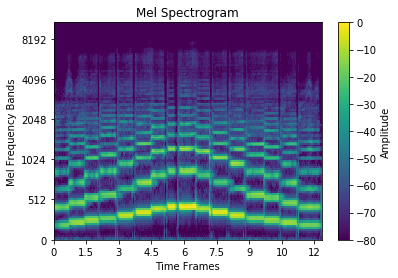

In [130]:
i = 5

plot_melspectrogram(train_df, 'clean_train', i)

# y, sr = sf.read('train/' + train_df['fname'][i])
# sd.play(y, sr)